# Code for visualizations used in the app

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns
import pingouin as pg
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio
pio.renderers.default = 'notebook' 

## 1. Importing data

In [2]:
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'

interventions_data = pd.read_csv(
    f'{url2}rta_df.csv')
aed_data =pd.read_csv(f'{url2}total_df_with_distances.csv')

# Load Belgium shapefile
belgium_boundary = gpd.read_file(f'{url2}Belgi%C3%AB.json')
# Load Belgium with regions shapefile
belgium_with_provinces_boundary = gpd.read_file(f'{url2}BELGIUM_-_Provinces.geojson')


## 2. Functions

In [3]:
# Function to create pointplots
def make_pointplot(df, x, y, hue=None):
    sns.set(style='whitegrid')
    sns.pointplot(x=x, y=y, data=df, hue=hue) # errorbars: 95% confidence interval
    plt.ylabel('Response Time')
    plt.xticks(rotation=90)


# Function to create Heatmaps
def make_heatmap(df, dv, between):
    if between != 'vector_type':
        rta_welsch_anova = df.sort_values(by=[dv, 'vector_type'], ascending=[True, True]).drop_duplicates(
        subset='Mission ID', keep='first')
    else:
        rta_welsch_anova = df[[dv, between]].dropna()

    # Reset indices
    rta_welsch_anova.reset_index(drop=True, inplace= True)
    
    # Post hoc Games Howell test
    gh = pg.pairwise_gameshowell(dv=dv, between=between, data=rta_welsch_anova)

    # Visualize p-values in the form of a heatmap
    # Pivot the results to get the p-values
    pval_matrix = gh.pivot(index='A', columns='B', values='pval').round(3)

    # Plot the heatmap
    sns.set(style='white')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pval_matrix, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
    plt.title('Pairwise p-values (Games-Howell)')

In [4]:
def make_plots(df, x, y, hue=None):
    # Create subplots with 1 row and 2 columns
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f'Pointplot of {y} vs {x}', 'Pairwise p-values (Games-Howell)'))

    # Pointplot
    scatter_fig = px.scatter(
        df,
        x=x,
        y=y,
        color=hue,
        error_y=df[y],  # Standard error for confidence intervals
        labels={y: 'Response Time'},
    )
    for trace in scatter_fig.data:
        fig.add_trace(trace, row=1, col=1)

    # Prepare data for heatmap
    if x != 'vector_type':
        rta_welsch_anova = df.sort_values(by=['log_response_time', 'vector_type'], ascending=[True, True]).drop_duplicates(
            subset='Mission ID', keep='first')
    else:
        rta_welsch_anova = df[[y, x]].dropna()

    # Reset indices
    rta_welsch_anova.reset_index(drop=True, inplace=True)

    # Post hoc Games Howell test
    gh = pg.pairwise_gameshowell(dv='log_response_time', between=x, data=rta_welsch_anova)

    # Pivot the results to get the p-values
    pval_matrix = gh.pivot(index='A', columns='B', values='pval').round(3)

    # Heatmap
    heatmap = go.Heatmap(
        z=pval_matrix.values,
        x=pval_matrix.columns,
        y=pval_matrix.index,
        colorscale='RdBu_r',
        colorbar=dict(title='p-value'),
        zmin=0, zmax=1,  # p-values range from 0 to 1
        text=pval_matrix.values,
        hoverinfo='text'
    )
    fig.add_trace(heatmap, row=1, col=2)

    # Update layout to adjust titles, size, etc.
    fig.update_layout(
        title_text="Combined Plot",
        xaxis_tickangle=-90,
        height=600,
        width=1000,
    )

    return fig


## 2. Visualizations RTA

In [5]:
# Renaming some variables for performing Welch's ANOVA
interventions_data['response_time'] = interventions_data['T3-T0']
interventions_data['vector_type'] = interventions_data['Vector type']
# Log-Transform the variable Response Time, because is right-skewed
interventions_data['log_response_time'] = interventions_data['response_time'].transform(np.log10)

### 2.1 By Province

#### 2.1.1 Averages

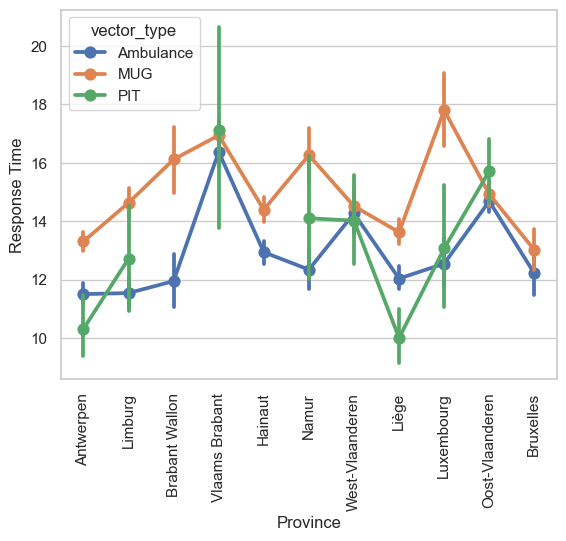

In [6]:
make_pointplot(df=interventions_data, x='Province', y='response_time', hue='vector_type')

In [7]:
#figure = make_plots(df=interventions_data, x='Province', y='response_time')
#figure.show()

#### 2.1.2 Heatmap

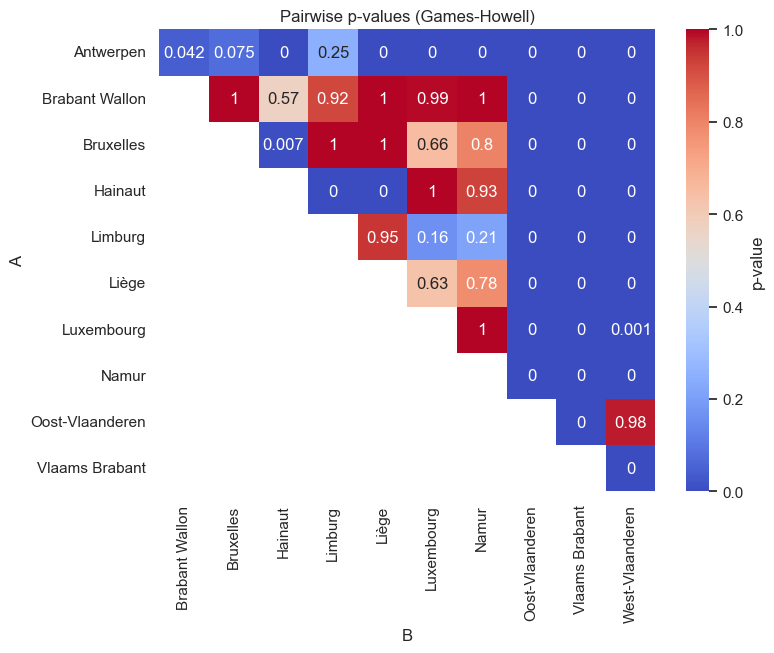

In [8]:
make_heatmap(df=interventions_data, dv='log_response_time', between='Province')

### 2.2 By Event Level

#### 2.2.1 Averages

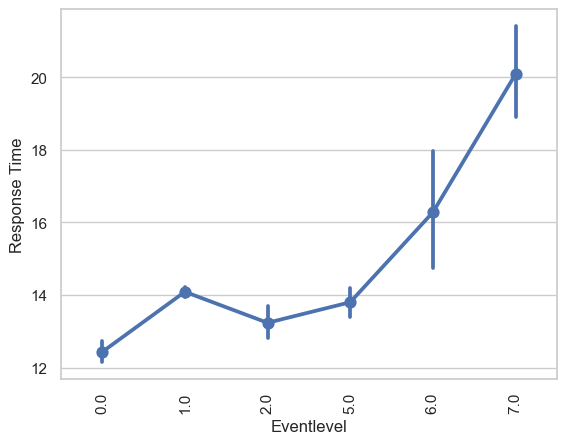

In [9]:
make_pointplot(df=interventions_data, x='Eventlevel', y='response_time')

#### 2.2.2 Heatmap

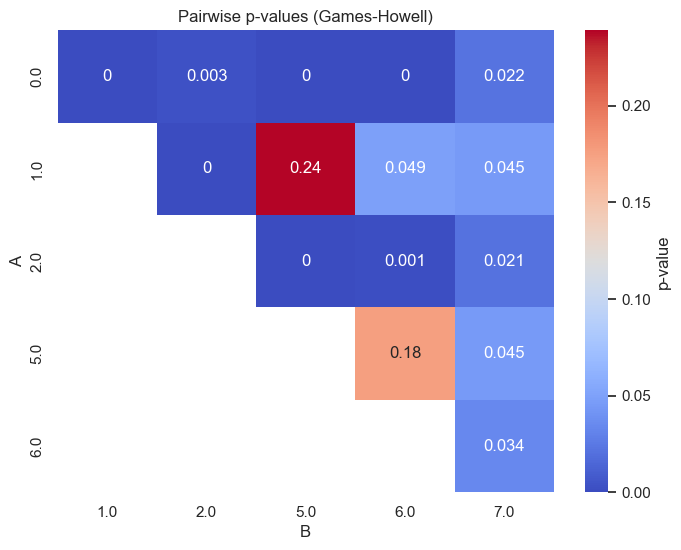

In [10]:
make_heatmap(df=interventions_data, dv='log_response_time', between='Eventlevel')

### 2.3 By Vector Type

#### 2.3.1 Averages

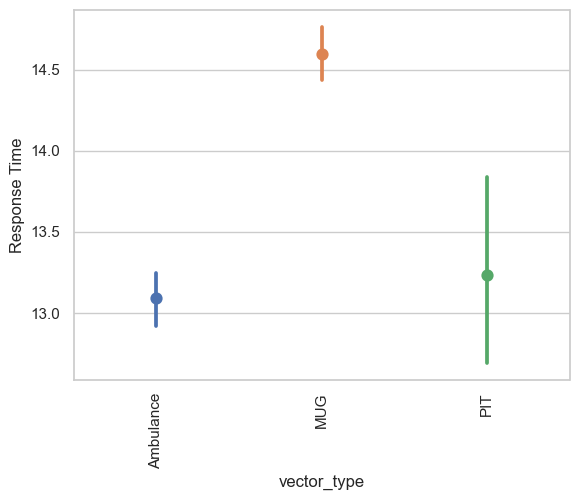

In [11]:
make_pointplot(df=interventions_data, x='vector_type', y='response_time', hue='vector_type')

#### 2.3.2 Heatmap

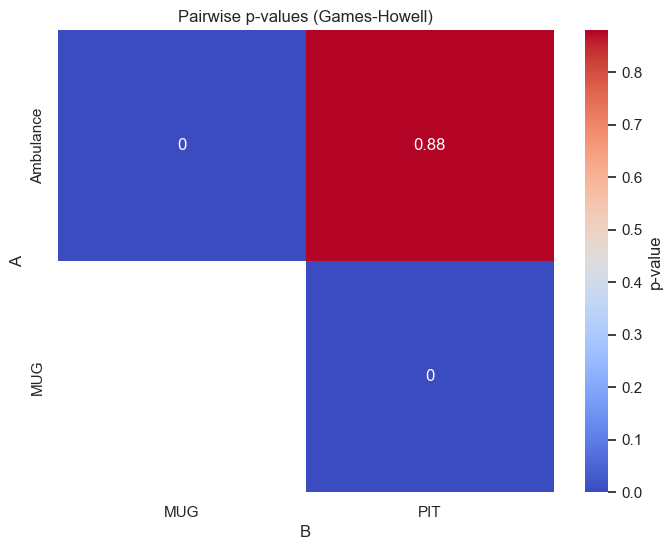

In [12]:
make_heatmap(df=interventions_data, dv='log_response_time', between='vector_type')

## 3. Visualizations AED